In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. X-RAY ORIGINAL ANALYZE

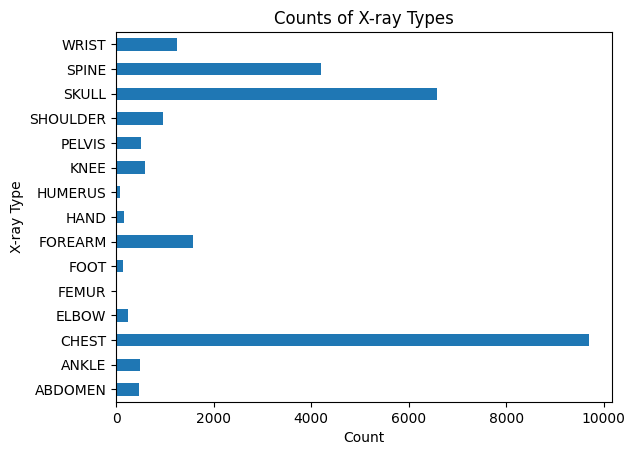

In [3]:
df_original = pd.read_csv('dataset_xray_original.csv')

grouped = df_original.groupby('xray_type')
grouped.size().plot(kind='barh', title='Counts of X-ray Types')
plt.xlabel('Count')
plt.ylabel('X-ray Type')
plt.show()

In [4]:
xray_counts = df_original['xray_type'].value_counts()
for xray_type, count in xray_counts.items():
    print(f"{xray_type}: {count}")

CHEST: 9693
SKULL: 6585
SPINE: 4194
FOREARM: 1573
WRIST: 1246
SHOULDER: 963
KNEE: 586
PELVIS: 514
ANKLE: 495
ABDOMEN: 475
ELBOW: 239
HAND: 166
FOOT: 143
HUMERUS: 80
FEMUR: 4


---

# 2. Save data noisy address

In [2]:
df_noise_address = pd.read_csv('dataset_noisy_address.csv')

In [11]:
import cv2
import easyocr
reader = easyocr.Reader(['en'])
for i in range(len(df_noise_address)):
    img_path = df_noise_address.iloc[i]['filepath']
    img = cv2.imread("../../" + img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = gray[0:500, 0:1000]
    results = reader.readtext(gray)
    patient_name = str(results[2][1])
    birth_year = ''
    if patient_name.split()[-1].isnumeric():
        birth_year = patient_name.split()[-1]
    x_ray_type = str(results[3][1])
    df_noise_address.at[i, 'patient_name'] = patient_name
    df_noise_address.at[i, 'birth_year'] = birth_year
    df_noise_address.at[i, 'xray_type'] = x_ray_type
    print(f"{i + 1}: Extracted patient_name: {patient_name} - birthday: {birth_year} - x-ray type: {x_ray_type} - from image: {img_path}")

df_noise_address.to_csv('dataset_noisy_address.csv', index=False)

1: Extracted patient_name: NGUYEN DUC THUAN 1971 - birthday: 1971 - x-ray type: L-SPINE AP - from image: ../XQUANG\20240226\20240226022\20240226022_20240226093436.jpg
2: Extracted patient_name: YA HOANG 2023 - birthday: 2023 - x-ray type: CHIESTT PA - from image: ../XQUANG\20240226\20240226037\20240226037_20240226115628.jpg
3: Extracted patient_name: RIA THUAN 2022 - birthday: 2022 - x-ray type: CHEST PA - from image: ../XQUANG\20240226\20240226039\20240226039_20240226122619.jpg
4: Extracted patient_name: YA YHU (EN 2013 - birthday: 2013 - x-ray type: FOFEAPMRAP - from image: ../XQUANG\20240226\20240226055\20240226055_20240226182601.jpg
5: Extracted patient_name: YA YHUYEN 2013 - birthday: 2013 - x-ray type: FOFEAPM RAP - from image: ../XQUANG\20240226\20240226055\20240226055_20240226182617.jpg
6: Extracted patient_name: SA LEM 1984 - birthday: 1984 - x-ray type: SKULL AP - from image: ../XQUANG\20240227\20240227024\20240227024_20240227094354.jpg
7: Extracted patient_name: HA HUU HAO 1

In [12]:
df_noise_address = pd.read_csv('dataset_noisy_address.csv')
df_noise_address['patient_name'] = df_noise_address['patient_name'].str.replace(r'[^a-zA-Z\s]', '', regex=True).str.upper()
df_noise_address.head()
df_noise_address.to_csv('dataset_noisy_address.csv', index=False)

In [18]:
import labled
from importlib import reload
reload(labled)

<module 'labled' from 'j:\\Preprocessing\\CleaningData\\clean_analyze_and_nomorlize\\labled.py'>

In [19]:
labled.process_dataset(
    'dataset_noisy_address.csv',
    output_files = {
        "XRAY_LABELS": "address/dataset_xray_original.csv",
        "LOCATION_NOISE": "address/dataset_noisy_address.csv",
        "VIETNAMESE_NAMES": "address/dataset_noisy_name.csv",
        "OTHERS": "address/dataset_noisy_other.csv"
    }
)

Đã đọc file dataset_noisy_address.csv với 3074 dòng.

--- BẮT ĐẦU XUẤT FILE ---
-> Đã xuất: address/dataset_xray_original.csv - Số lượng: 3005
   (Ghi chú: Cột xray_type trong file này đã được chuẩn hóa)
-> Đã xuất: address/dataset_noisy_address.csv - Số lượng: 4
   (Ghi chú: Cột xray_type giữ nguyên gốc để kiểm tra)
-> Đã xuất: address/dataset_noisy_name.csv - Số lượng: 19
   (Ghi chú: Cột xray_type giữ nguyên gốc để kiểm tra)
-> Đã xuất: address/dataset_noisy_other.csv - Số lượng: 46
   (Ghi chú: Cột xray_type giữ nguyên gốc để kiểm tra)

Hoàn tất xử lý!


---

# 3. Save data noisy name

In [20]:
df_noise_name = pd.read_csv('dataset_noisy_name.csv')

In [22]:
import cv2
import easyocr
reader = easyocr.Reader(['en'])
for i in range(len(df_noise_name)):
    img_path = df_noise_name.iloc[i]['filepath']
    img = cv2.imread("../../" + img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = gray[0:500, 0:1000]
    results = reader.readtext(gray)
    patient_name = str(results[2][1])
    birth_year = ''
    if patient_name.split()[-1].isnumeric():
        birth_year = patient_name.split()[-1]
    x_ray_type = str(results[3][1])
    #df_noise_name.at[i, 'patient_name'] = patient_name
    #df_noise_name.at[i, 'birth_year'] = birth_year
    df_noise_name.at[i, 'xray_type'] = x_ray_type
    print(f"{i + 1}: Extracted patient_name: {patient_name} - birthday: {birth_year} - x-ray type: {x_ray_type} - from image: {img_path}")

df_noise_name.to_csv('dataset_noisy_name.csv', index=False)

1: Extracted patient_name: NGUYEN THI HANG 1979 - birthday: 1979 - x-ray type: FOOT R AP - from image: ../XQUANG\20240226\20240226016\20240226016_20240226091740.jpg
2: Extracted patient_name: NGUYEN THI HANG 1979 - birthday: 1979 - x-ray type: FOOT RAP - from image: ../XQUANG\20240226\20240226016\20240226016_20240226091801.jpg
3: Extracted patient_name: NGUYEN THI THU THAI 0 199 - birthday: 199 - x-ray type: SKULL AP - from image: ../XQUANG\20240226\20240226020\20240226020_20240226092944.jpg
4: Extracted patient_name: NGUYEN THI THU THAI 0 199 - birthday: 199 - x-ray type: SKULL AP - from image: ../XQUANG\20240226\20240226020\20240226020_20240226093011.jpg
5: Extracted patient_name: NGUYEN THI THU THAI 0 199 - birthday: 199 - x-ray type: SKULL AP - from image: ../XQUANG\20240226\20240226020\20240226020_20240226093032.jpg
6: Extracted patient_name: NGUYEN THI THU THAI 0 199 - birthday: 199 - x-ray type: SKULL AP - from image: ../XQUANG\20240226\20240226020\20240226020_20240226093047.jpg

In [23]:
df_noise_name = pd.read_csv('dataset_noisy_name.csv')
df_noise_name['patient_name'] = df_noise_name['patient_name'].str.replace(r'[^a-zA-Z\s]', '', regex=True).str.upper()
df_noise_name.head()
df_noise_name.to_csv('dataset_noisy_address.csv', index=False)

In [25]:
labled.process_dataset(
    'dataset_noisy_name.csv',
    output_files = {
        "XRAY_LABELS": "name/dataset_xray_original.csv",
        "LOCATION_NOISE": "name/dataset_noisy_address.csv",
        "VIETNAMESE_NAMES": "name/dataset_noisy_name.csv",
        "OTHERS": "name/dataset_noisy_other.csv"
    }
)

Đã đọc file dataset_noisy_name.csv với 4801 dòng.

--- BẮT ĐẦU XUẤT FILE ---
-> Đã xuất: name/dataset_xray_original.csv - Số lượng: 4729
   (Ghi chú: Cột xray_type trong file này đã được chuẩn hóa)
-> Đã xuất: name/dataset_noisy_address.csv - Số lượng: 2
   (Ghi chú: Cột xray_type giữ nguyên gốc để kiểm tra)
-> Đã xuất: name/dataset_noisy_name.csv - Số lượng: 24
   (Ghi chú: Cột xray_type giữ nguyên gốc để kiểm tra)
-> Đã xuất: name/dataset_noisy_other.csv - Số lượng: 46
   (Ghi chú: Cột xray_type giữ nguyên gốc để kiểm tra)

Hoàn tất xử lý!


---

# 4. Save data noisy other

In [27]:
df_noise_other = pd.read_csv('dataset_noisy_other.csv')

In [28]:
import cv2
import easyocr
reader = easyocr.Reader(['en'])
for i in range(len(df_noise_other)):
    img_path = df_noise_other.iloc[i]['filepath']
    img = cv2.imread("../../" + img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = gray[0:500, 0:1000]
    results = reader.readtext(gray)
    patient_name = str(results[2][1])
    birth_year = ''
    if patient_name.split()[-1].isnumeric():
        birth_year = patient_name.split()[-1]
    x_ray_type = str(results[3][1])
    #df_noise_name.at[i, 'patient_name'] = patient_name
    #df_noise_name.at[i, 'birth_year'] = birth_year
    df_noise_other.at[i, 'xray_type'] = x_ray_type
    print(f"{i + 1}: Extracted patient_name: {patient_name} - birthday: {birth_year} - x-ray type: {x_ray_type} - from image: {img_path}")

df_noise_other.to_csv('dataset_noisy_other.csv', index=False)

1: Extracted patient_name: LAM VIET PHUONG - birthday:  - x-ray type: KNEE RAP - from image: ../XQUANG\20240226\20240226023\20240226023_20240226094516.jpg
2: Extracted patient_name: LAM VIET PHUONG - birthday:  - x-ray type: KNEE RAP - from image: ../XQUANG\20240226\20240226023\20240226023_20240226094532.jpg
3: Extracted patient_name: DINH THI NGA 1962 - birthday: 1962 - x-ray type: KNEE RAP - from image: ../XQUANG\20240227\20240227006\20240227006_20240227082015.jpg
4: Extracted patient_name: DINH DUC DUC 1958 - birthday: 1958 - x-ray type: KNEE RAP - from image: ../XQUANG\20240227\20240227011\20240227011_20240227083700.jpg
5: Extracted patient_name: DINH DUC DUC 1958 - birthday: 1958 - x-ray type: KNEE RAP - from image: ../XQUANG\20240227\20240227011\20240227011_20240227083725.jpg
6: Extracted patient_name: YA SANG 1996 - birthday: 1996 - x-ray type: KNEE RAP - from image: ../XQUANG\20240227\20240227029\20240227029_20240227102353.jpg
7: Extracted patient_name: YA SANG 1996 - birthday:

In [29]:
df_noise_other = pd.read_csv('dataset_noisy_other.csv')
df_noise_other['patient_name'] = df_noise_other['patient_name'].str.replace(r'[^a-zA-Z\s]', '', regex=True).str.upper()
df_noise_other.head()
df_noise_other.to_csv('dataset_noisy_other.csv', index=False)

In [30]:
labled.process_dataset(
    'dataset_noisy_other.csv',
    output_files = {
        "XRAY_LABELS": "other/dataset_xray_original.csv",
        "LOCATION_NOISE": "other/dataset_noisy_address.csv",
        "VIETNAMESE_NAMES": "other/dataset_noisy_name.csv",
        "OTHERS": "other/dataset_noisy_other.csv"
    }
)

Đã đọc file dataset_noisy_other.csv với 3849 dòng.

--- BẮT ĐẦU XUẤT FILE ---
-> Đã xuất: other/dataset_xray_original.csv - Số lượng: 3796
   (Ghi chú: Cột xray_type trong file này đã được chuẩn hóa)
-> Đã xuất: other/dataset_noisy_address.csv - Số lượng: 4
   (Ghi chú: Cột xray_type giữ nguyên gốc để kiểm tra)
-> Đã xuất: other/dataset_noisy_name.csv - Số lượng: 11
   (Ghi chú: Cột xray_type giữ nguyên gốc để kiểm tra)
-> Đã xuất: other/dataset_noisy_other.csv - Số lượng: 38
   (Ghi chú: Cột xray_type giữ nguyên gốc để kiểm tra)

Hoàn tất xử lý!


---

# 5. Merge file

In [31]:
df_original = pd.read_csv('dataset_xray_original.csv')
df_address_original = pd.read_csv('address/dataset_xray_original.csv')
df_name_original = pd.read_csv('name/dataset_xray_original.csv')
df_other_original = pd.read_csv('other/dataset_xray_original.csv')

combined = pd.concat([df_original, df_address_original, df_name_original, df_other_original]).drop_duplicates().reset_index(drop=True)
combined.to_csv('dataset_xray_original_combined.csv', index=False)

In [35]:
# Check duplicates 'filepath' column
duplicates = combined[combined.duplicated(subset=['filepath'], keep=False)]
print(f"Number of duplicate filepaths: {len(duplicates)}")
print(len(combined))

Number of duplicate filepaths: 0
38486


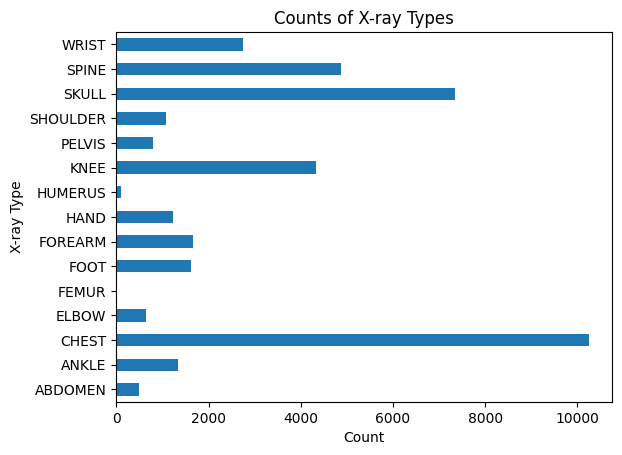

In [33]:
grouped = combined.groupby('xray_type')
grouped.size().plot(kind='barh', title='Counts of X-ray Types')
plt.xlabel('Count')
plt.ylabel('X-ray Type')
plt.show()

In [34]:
xray_counts = combined['xray_type'].value_counts()
for xray_type, count in xray_counts.items():
    print(f"{xray_type}: {count}")

CHEST: 10244
SKULL: 7344
SPINE: 4872
KNEE: 4335
WRIST: 2746
FOREARM: 1658
FOOT: 1616
ANKLE: 1331
HAND: 1236
SHOULDER: 1079
PELVIS: 791
ELBOW: 644
ABDOMEN: 484
HUMERUS: 101
FEMUR: 5
